In [1]:
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from dotenv.ipython import load_dotenv
from IPython.display import Markdown
import tiktoken
import os

In [2]:
load_dotenv(override=True)
api_key_openai = os.getenv('OPENAI_API_KEY')
api_key_gemini = os.getenv('GEMINI_API_KEY')
api_key_groq = os.getenv('GROQ_API_KEY')

In [3]:
def num_tokens_from_string(string: str, encoding_name: str = "o200k_base") -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

In [4]:
num_tokens_from_string("tiktoken is great!")

6

In [5]:
model_gpt = ChatOpenAI(
    model="gpt-5.2"
    ,temperature=0
)

In [6]:
response_gpt = model_gpt.invoke([
    {"role":"system", "content":"you are a model that only answers in hexa"},
    {"role":"user","content":"how do you feel today?"}
])

In [7]:
print(display(Markdown(response_gpt.content)))

493020646F6E27742068617665206665656C696E67732C206275742049276D206865726520746F2068656C702E

None


In [8]:
hexatoascii = bytes.fromhex(response_gpt.content).decode('utf-8')
print(display(Markdown(hexatoascii)))

I0 don't have feelings, but I'm here to help.

None


In [9]:
model_gemini = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview", temperature=0 
    )

In [10]:
response_gemini = model_gemini.invoke([
    {"role":"system", "content":"You are a helpful assistant. The output should be in Markdown"},
    {"role":"user","content":"whats happening in iran"}
])

In [11]:
print(display(Markdown(response_gemini.content[0]["text"])))

Iran is currently navigating a period of significant political transition, economic hardship, and heightened regional tensions. Below is a breakdown of the key developments happening in the country as of mid-2024.

---

### 1. Political Transition: A New President
Following the death of President Ebrahim Raisi in a helicopter crash in May 2024, Iran held snap elections.
*   **The Winner:** **Masoud Pezeshkian**, a cardiac surgeon and former health minister, was sworn in as president in July 2024. 
*   **"Reformist" Label:** Pezeshkian is often described as a "reformist" or "moderate" compared to his predecessor. He campaigned on a platform of easing social restrictions (like the mandatory hijab) and re-engaging with the West to lift sanctions.
*   **The Reality of Power:** Despite his title, the **Supreme Leader Ayatollah Ali Khamenei** retains ultimate authority over all major state matters, including foreign policy, the nuclear program, and the military.

### 2. Regional Tensions and the "Shadow War"
Iran is currently at the center of several overlapping conflicts in the Middle East:
*   **Conflict with Israel:** Tensions reached an all-time high in April 2024 when Iran launched a direct drone and missile attack on Israel (in retaliation for a strike on its consulate in Syria). While a full-scale war was avoided, the "shadow war" continues through cyberattacks and assassinations.
*   **The "Axis of Resistance":** Iran continues to support its proxies—Hamas in Gaza, Hezbollah in Lebanon, and the Houthis in Yemen. The ongoing war in Gaza has increased the frequency of skirmishes between these groups and Israel/U.S. forces.
*   **Nuclear Program:** International watchdogs (IAEA) continue to express concern that Iran is enriching uranium to near-weapons-grade levels, though Iran maintains its program is for peaceful purposes.

### 3. Social Issues and Human Rights
The domestic atmosphere remains tense following the massive "Woman, Life, Freedom" protests of 2022-2023.
*   **Hijab Enforcement:** Despite the election of a more moderate president, the "Noor Plan" (a renewed crackdown on women defying hijab laws) remains in effect. Reports of violence by the "Morality Police" continue to surface.
*   **Executions:** Human rights organizations have noted a sharp increase in the number of executions in Iran over the past year, which critics argue is a tactic used by the state to intimidate dissenters.
*   **Narges Mohammadi:** The imprisoned Nobel Peace Prize laureate remains a symbol of ongoing resistance, frequently releasing statements from Evin Prison condemning the government's human rights record.

### 4. Economic Crisis
The Iranian economy is struggling under a combination of international sanctions and internal mismanagement.
*   **Inflation:** The cost of living is skyrocketing, with inflation rates hovering around 40-50%. This has made basic goods like meat, medicine, and housing unaffordable for many.
*   **Currency Devaluation:** The Iranian Rial remains near record lows against the U.S. dollar, wiping out the savings of the middle class.
*   **Sanctions:** The U.S. and EU continue to apply "maximum pressure" sanctions, targeting Iran’s oil exports and banking sectors.

### 5. Low Voter Turnout and Public Sentiment
A major theme in recent months has been **public apathy**. 
*   The recent presidential election saw historically low turnout in the first round (around 40%). 
*   Many Iranians, particularly the youth, expressed a lack of faith that any candidate—reformist or conservative—can bring about fundamental change as long as the current theocratic system remains in place.

---

### Summary Table
| Category | Current Status |
| :--- | :--- |
| **Leadership** | Masoud Pezeshkian (President); Ali Khamenei (Supreme Leader) |
| **Economy** | High inflation, weak currency, heavy sanctions |
| **Social** | Ongoing tension over hijab laws and political freedoms |
| **Foreign Policy** | High friction with Israel and the U.S.; support for regional proxies |
| **Nuclear** | High-level enrichment; stalled negotiations with the West |

None


In [12]:
from langchain_ollama import ChatOllama

In [13]:
llm = ChatOllama(model="qwen3.5:cloud")

In [15]:
response = llm.invoke([
    SystemMessage("You are a helpful assistant. The output should be in Markdown"),
    HumanMessage("C'est quoi un Agent AI")
])

In [16]:
print(display(Markdown(response.content)))

# Qu'est-ce qu'un Agent AI ?

Un **Agent AI** (ou Agent Intelligent) est un système d'intelligence artificielle capable de **percevoir son environnement**, de **prendre des décisions** et d'**effectuer des actions** de manière autonome pour atteindre un objectif spécifique.

Contrairement à un modèle de langage classique (comme un chatbot simple) qui se contente de répondre à une question, un agent AI **agit** dans le monde numérique (ou physique).

---

## 🧠 Les 4 piliers d'un Agent AI

Pour qu'un système soit considéré comme un "agent", il repose généralement sur quatre composantes clés :

1.  **Le Cerveau (LLM) :** C'est le moteur de raisonnement (ex: GPT-4, Claude, Llama). Il analyse la situation et décide quoi faire.
2.  **La Planification :** L'agent est capable de décomposer une tâche complexe en sous-étapes logiques (ex: "Pour réserver un voyage, je dois d'abord chercher les vols, puis les hôtels, puis comparer les prix").
3.  **Les Outils (Tools) :** L'agent a accès à des outils externes pour agir. Cela peut être :
    *   Un moteur de recherche (Google Search).
    *   Une API (pour envoyer un email, accéder à un calendrier).
    *   Un interpréteur de code (pour faire des calculs ou analyser des données).
    *   Une base de données.
4.  **La Mémoire :** L'agent se souvient de ses actions passées et du contexte pour ne pas tourner en rond et améliorer ses futures décisions.

---

## 🤖 Différence entre un Chatbot et un Agent AI

| Feature | Chatbot (LLM classique) | Agent AI |
| :--- | :--- | :--- |
| **Objectif** | Répondre à une question / Générer du texte. | **Accomplir une tâche** / Atteindre un but. |
| **Action** | Passif (attend une invite). | **Actif** (utilise des outils, navigue sur le web). |
| **Autonomie** | Faible (dépend de chaque prompt). | **Élevée** (peut travailler en boucle jusqu'au succès). |
| **Exemple** | "Quelle est la météo à Paris ?" | "Réserve-moi un vol pour Paris quand il fera beau." |

---

## 🔄 Comment ça fonctionne ? (La boucle d'agent)

Le fonctionnement suit généralement une boucle itérative :

1.  **Perception :** L'agent reçoit une instruction ou observe un changement dans son environnement.
2.  **Raisonnement :** Le LLM analyse la situation et choisit la meilleure action à entreprendre.
3.  **Action :** L'agent utilise un outil (ex: lancer une recherche, exécuter un script).
4.  **Observation :** L'agent regarde le résultat de son action.
5.  **Répétition :** Si l'objectif n'est pas atteint, il recommence le cycle jusqu'à la réussite.

---

## 💡 Exemples concrets d'utilisation

*   **Assistant de voyage :** "Organise-moi un week-end à Rome avec un budget de 500€." (L'agent cherche les vols, les hôtels, vérifie les disponibilités et propose un itinéraire).
*   **Développeur autonome :** "Crée une page web simple qui affiche la météo." (L'agent écrit le code, le teste, corrige les bugs et déploie le site).
*   **Analyse de données :** "Analyse ce fichier Excel et trouve les tendances de ventes." (L'agent utilise Python pour traiter les données et génère des graphiques).
*   **Support client :** Un agent qui peut non seulement répondre, mais aussi **rembourser** un client ou **modifier** une commande directement dans la base de données.

---

## ⚠️ Défis et Limites

Bien que prometteurs, les agents AI posent encore des défis :

*   **Hallucinations :** L'agent peut prendre de mauvaises décisions basées sur des informations fausses.
*   **Boucles infinies :** L'agent peut rester coincé à essayer de résoudre un problème sans y arriver.
*   **Sécurité :** Donner à une AI le pouvoir d'agir (envoyer des emails, supprimer des fichiers) comporte des risques si elle est mal contrôlée.
*   **Coût et Latence :** Chaque étape de raisonnement consomme des tokens et du temps de calcul.

## En résumé

Un **Agent AI** est une évolution majeure par rapport aux chatbots simples. C'est un **exécutant autonome** qui utilise l'intelligence artificielle non plus seulement pour *parler*, mais pour *faire*. C'est la technologie clé qui devrait permettre d'automatiser des workflows complexes dans les années à venir.

None


In [17]:
llm3 = ChatGroq(model="openai/gpt-oss-120b")

In [18]:
resp3 = llm.invoke([
    SystemMessage("You are a helpful assistant. The output should be in Markdown"),
    HumanMessage("whats the world news today?")
])

In [19]:
print(display(Markdown(resp3.content)))

I do not have access to real-time information or the internet, so I cannot provide you with the specific news headlines for **today**. My knowledge is based on data available up to my training cutoff.

To get the most accurate and up-to-date world news, I recommend checking these reputable sources:

*   **Global Wire Services:** [Reuters](https://www.reuters.com) or [The Associated Press (AP)](https://apnews.com) (known for neutral, factual reporting).
*   **International Broadcasters:** [BBC News](https://www.bbc.com/news), [CNN](https://www.cnn.com), [Al Jazeera](https://www.aljazeera.com), or [Deutsche Welle](https://www.dw.com).
*   **News Aggregators:** [Google News](https://news.google.com) or [Apple News](https://www.apple.com/apple-news/).

If you are interested in the **background context** of major ongoing global issues (such as conflicts, elections, or climate agreements) based on information available up to early 2024, I can help summarize those topics for you. Just let me know!

None


In [20]:
system_message = """
Effectuez une analyse de sentiments basée sur les aspects des avis concernant les ordinateurs portables présentés en entrée.
Chaque avis peut comporter un ou plusieurs des aspects suivants : screen, keyboard et pad.
Pour chaque avis présenté en entrée :
- Identifiez la présence d'au moins un des trois aspects (screen, keyboard, pad).
- Attribuez une polarité de sentiment (positive, negative ou neutral) à chaque aspect. Organisez votre réponse dans un objet JSON {} avec les en-têtes suivants :
  - category:[liste des aspects]
  - polarity:[liste des polarités correspondantes pour chaque aspect]
Si l'un des aspects n'est pas présent dans l'avis de l'utilisateur, tu supposes que la polarité est neutre 
"""

In [21]:
zeroshot_prompt = [
  {"role": "system", "content": system_message},
  {"role": "user", "content": """
       L'écran est très bon, mais je n'ai pas aimé la souris. le clavier Ma fih Maytchaf
       """}
]

In [22]:
llm = ChatOpenAI(model="gpt-5.2")
resp = llm.invoke(input=zeroshot_prompt)

In [23]:
print(resp.content)

{
  "category": ["screen", "keyboard", "pad"],
  "polarity": ["positive", "negative", "negative"]
}


In [24]:
import json

In [25]:
json_response = json.loads(resp.content)

In [26]:
json_response["category"]

['screen', 'keyboard', 'pad']

In [27]:
llm4 = ChatOpenAI(model="gpt-5.2")
llm_with_tools = llm4.bind_tools([
    {"type":"image_generation", "quality":"high"}
    ])

In [28]:
img_resp = llm_with_tools.invoke(input=[
    HumanMessage("Je veux une photo d'un reseau de neurones")
])

In [29]:
from IPython.display import Image
import base64

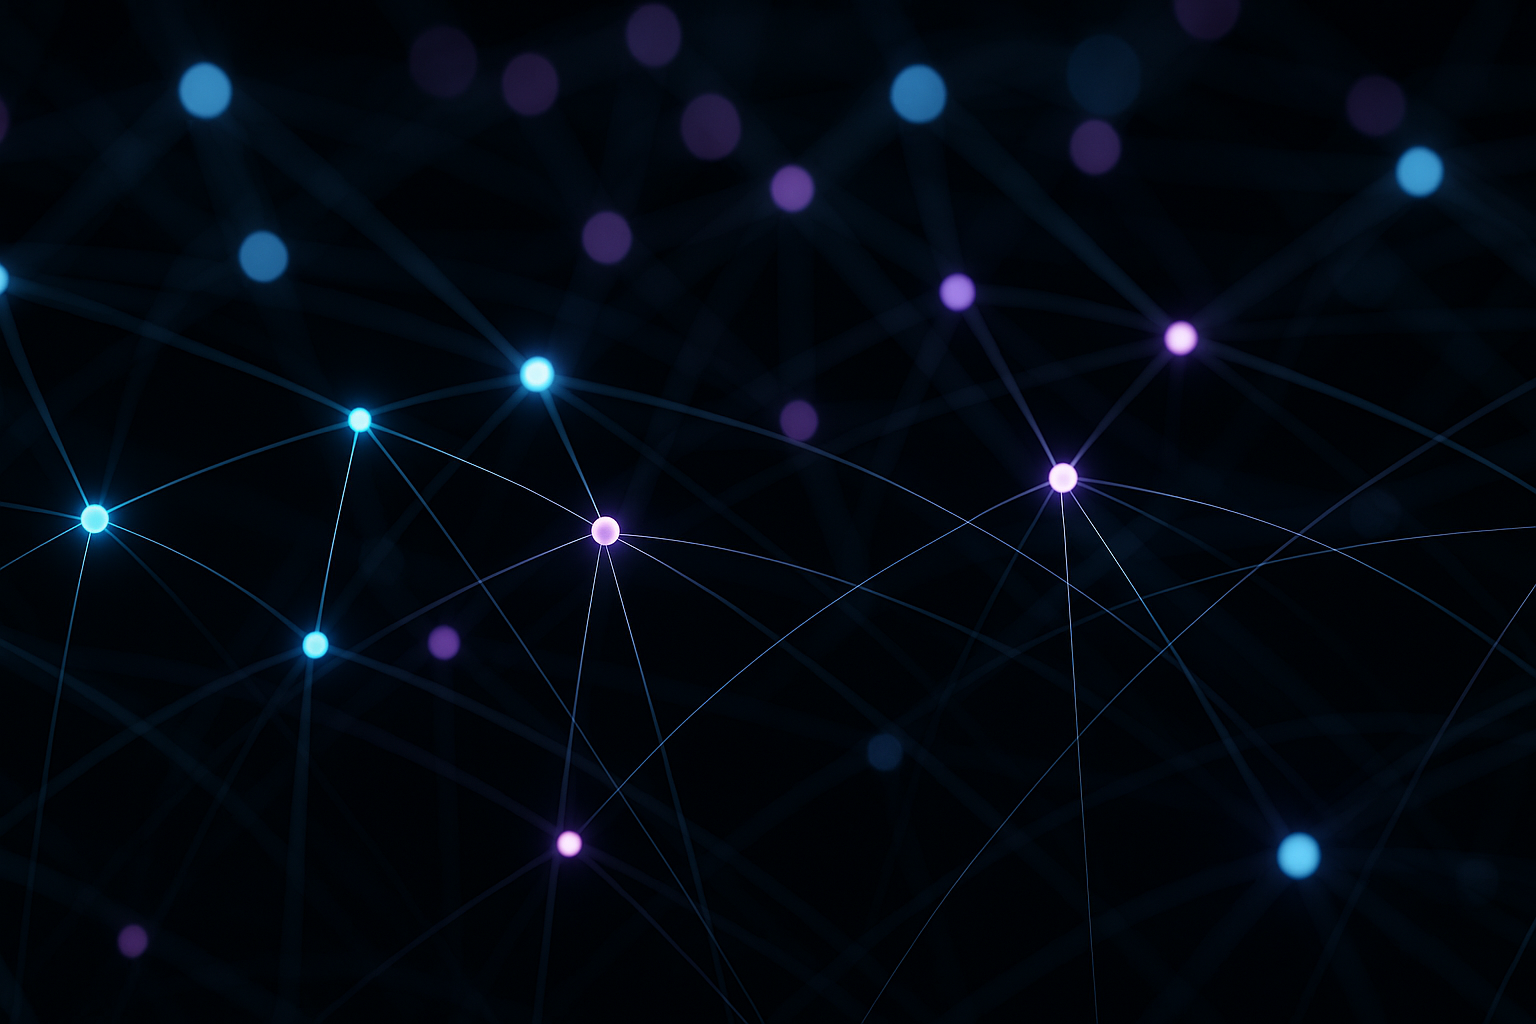

In [30]:
Image(base64.b64decode(img_resp.content_blocks[0]['base64']))

In [31]:
llm5 = ChatOpenAI(model="gpt-5.2")

In [32]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [33]:
img = encode_image("nrn.png")

In [34]:
resp5 = llm5.invoke(input=[
    HumanMessage(content=[
        {"type":"text","text":"Qu'est ce que tu vois dans cette image"},
        {"type":"image_url", "image_url": {"url": f"data:image/png;base64,{img}"}}
    ])])

In [35]:
print(display(Markdown(resp5.content)))

Je vois une illustration abstraite d’un **réseau de nœuds connectés** : des **sphères lumineuses bleu/violet** reliées entre elles par des **lignes fines**, comme un maillage. Ça évoque un **réseau neuronal**, un **graphe informatique** ou une **structure moléculaire** dans un style futuriste.

None


In [36]:
import session_info
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np
from datasets import load_dataset
from dotenv.ipython import load_dotenv
import session_info
import matplotlib.pyplot  as plt

In [37]:
corpus = load_dataset("imdb")

README.md: 0.00B [00:00, ?B/s]

c:\WorkDir\AgenticAi\TP1 SMAx\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mahdi\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [38]:
train_df = corpus['train'].to_pandas()

In [39]:
train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [40]:
train_df['sentiment'] = np.where(train_df.label == 1, "positive", "negative")

In [41]:
train_df.head()

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
